In [268]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings 

In [269]:
warnings.filterwarnings('ignore')

In [270]:
df = pd.read_csv('11-Iris.csv')

In [271]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [272]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [273]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [274]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [275]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [276]:
df = df.drop("Id", axis=1)

In [277]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


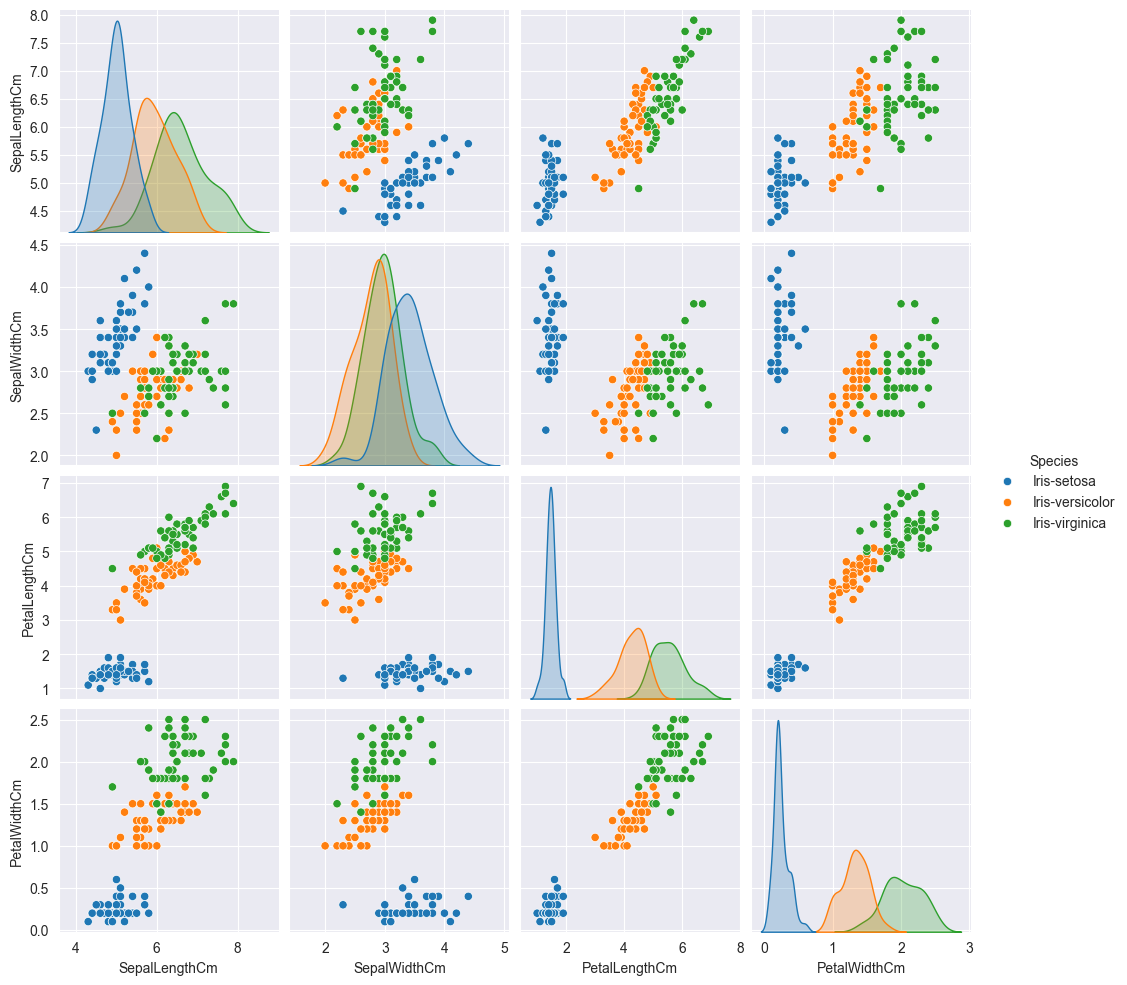

In [278]:
# Data Visualization

sns.pairplot(df, hue="Species")
plt.show()

In [279]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

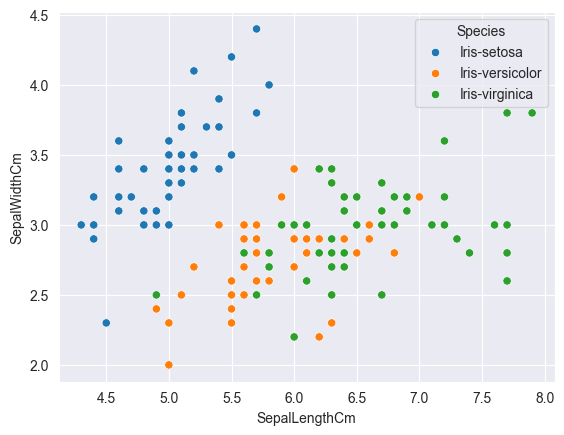

In [280]:
sns.scatterplot(x=df["SepalLengthCm"], y=df["SepalWidthCm"], hue=df["Species"])
plt.show()

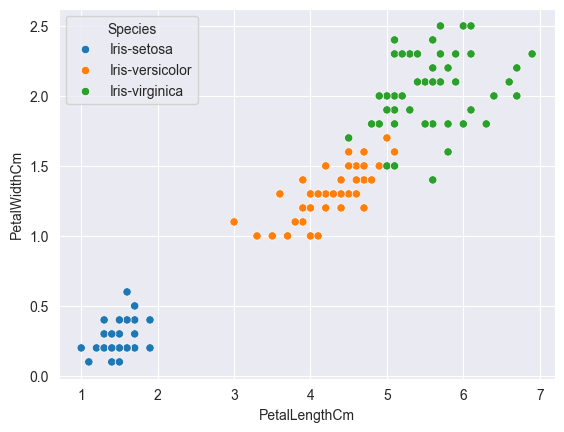

In [281]:
sns.scatterplot(x=df["PetalLengthCm"], y=df["PetalWidthCm"], hue=df["Species"])
plt.show()

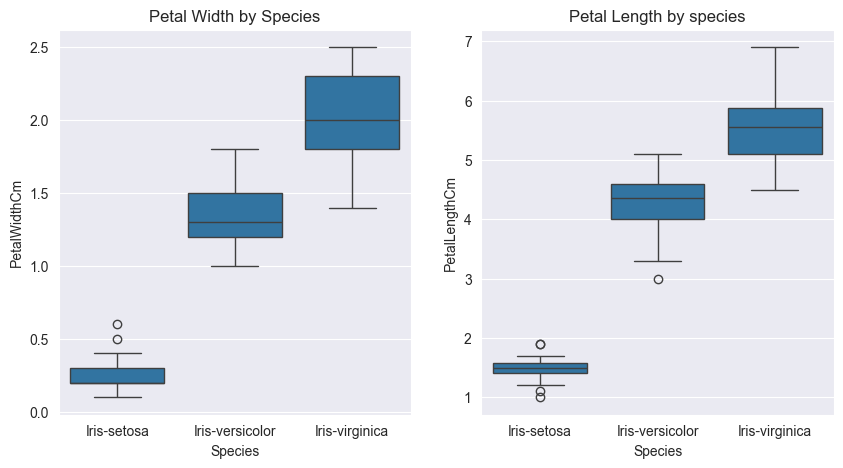

In [282]:
plt.figure(figsize=(10,5))
sns.set_style("darkgrid")

plt.subplot(1,2,1)
plt.title("Petal Width by Species")
sns.boxplot(data=df, x="Species", y="PetalWidthCm")
plt.subplot(1,2,2)
plt.title("Petal Length by species")
sns.boxplot(data=df, x="Species", y="PetalLengthCm")
plt.show()

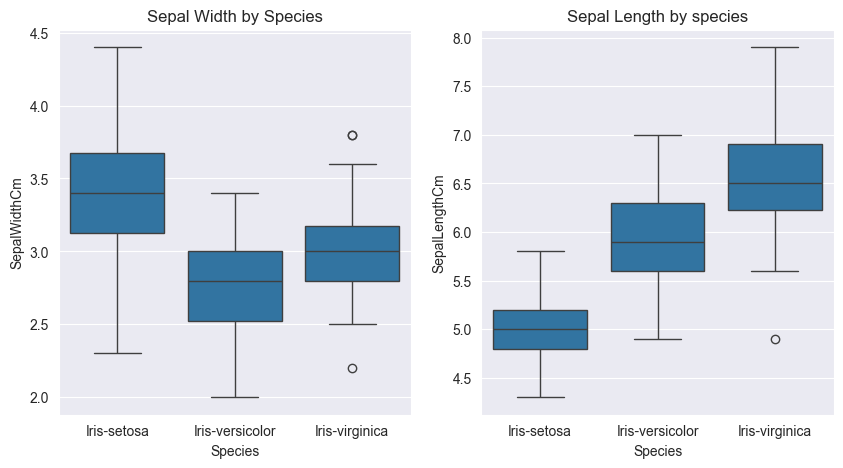

In [283]:
plt.figure(figsize=(10,5))
sns.set_style("darkgrid")

plt.subplot(1,2,1)
plt.title("Sepal Width by Species")
sns.boxplot(data=df, x="Species", y="SepalWidthCm")
plt.subplot(1,2,2)
plt.title("Sepal Length by species")
sns.boxplot(data=df, x="Species", y="SepalLengthCm")
plt.show()

In [284]:
# ENCODİNG

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [285]:
df["Species"] = label_encoder.fit_transform(df["Species"])

In [286]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [287]:
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [288]:
df["Species"].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [289]:
X = df.drop("Species", axis=1)
y = df["Species"]

In [290]:
from sklearn.model_selection import train_test_split

In [291]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=15) 

In [292]:
# Bernoulli ve Multinomial Naive Bayes'te scale işlemi yapmaya gerek yok. Ama Gaussian Naive Bayeste sürekli değişkenler olduğu için
# scale edersek daha iyi olur. Biz burada sürekli değişkenler olduğu için Gaussian kullanacağız bu sebeple scale edelim!

In [293]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [294]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [295]:
# Classification

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [296]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_scaled,y_train)
y_pred_nb = gnb.predict(X_test_scaled)

print("accuracy_score: ", accuracy_score(y_test,y_pred_nb))
print(classification_report(y_test,y_pred_nb))
print("confusion_matrix: \n" ,confusion_matrix(y_test,y_pred_nb))

accuracy_score:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        14

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

confusion_matrix: 
 [[15  0  0]
 [ 0 16  0]
 [ 0  0 14]]


In [297]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression()
logistic.fit(X_train_scaled,y_train)
y_pred_logistic  = logistic.predict(X_test_scaled)

print("accuracy_score: ", accuracy_score(y_test,y_pred_logistic))
print(classification_report(y_test,y_pred_logistic))
print("confusion_matrix: \n" ,confusion_matrix(y_test,y_pred_logistic))

accuracy_score:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        14

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

confusion_matrix: 
 [[15  0  0]
 [ 0 16  0]
 [ 0  0 14]]


In [298]:
# Support Vector Classifier

from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train_scaled,y_train)
y_pred_svc = svc.predict(X_test_scaled)

print("accuracy_score: ", accuracy_score(y_test,y_pred_svc))
print(classification_report(y_test,y_pred_svc))
print("confusion_matrix: \n" ,confusion_matrix(y_test,y_pred_svc))

accuracy_score:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        14

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

confusion_matrix: 
 [[15  0  0]
 [ 0 16  0]
 [ 0  0 14]]
